# Spor Analitiği — Açık Futbol Lig İstatistikleri

**Veri Bilimi Dönem Projesi**

Bu notebook, İngiltere Premier Lig'in **2020-21 → 2023-24** sezonlarına ait açık maç
istatistiklerini kullanarak uçtan uca bir veri bilimi çalışması içerir: veri yükleme,
temizleme (eksik veri senaryosu + doldurma, aykırı değer), keşifsel veri analizi (EDA),
araştırma sorularının analizle ve **istatistiksel hipotez testiyle** yanıtlanması ve basit
bir sınıflandırma modeli.

## Amaç
Maç içi istatistiklerin (şut, isabetli şut, korner, faul, kart, ilk yarı skoru) maç
sonucuyla ilişkisini incelemek ve bu istatistiklerle maç sonucunu (Ev galibiyeti /
Beraberlik / Deplasman galibiyeti) tahmin eden bir model kurmak.

## Araştırma Soruları
1. **Ev sahibi avantajı** gerçekten istatistiksel olarak gözlemlenebilir mi?
2. Hangi maç içi istatistik, **gol farkıyla (maç üstünlüğü)** en güçlü ilişkiye sahiptir?
3. **İlk yarıyı önde kapatmak**, maç sonucunu ne ölçüde belirler?

## Veri Kaynağı
- **Kaynak:** datahub.io / GitHub `datasets/football-datasets` (orijinal kaynak: football-data.co.uk)
- **Lisans:** Open Data Commons Public Domain Dedication and License (PDDL) v1.0
- **Kapsam:** 4 sezon × 380 maç = 1520 maç

## 1. Kütüphanelerin Yüklenmesi
Analiz boyunca kullanacağımız kütüphaneleri içe aktarıyor ve görselleştirme ayarlarını
yapıyoruz. Tekrarlanabilirlik için rastgelelik tohumunu (`seed`) sabitliyoruz.

In [1]:
# Veri isleme
import numpy as np
import pandas as pd
from pathlib import Path

# Gorsellestirme
import matplotlib.pyplot as plt
import seaborn as sns

# Istatistik (eksik veri senaryosu + hipotez testi icin)
from scipy import stats
from scipy.stats import binomtest

# Makine ogrenmesi (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Grafiklerin notebook icinde gorunmesi
%matplotlib inline

# Genel gorsel stil ve tekrarlanabilirlik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
RANDOM_STATE = 42            # Tum rastgele islemlerde ayni sonucu almak icin
np.random.seed(RANDOM_STATE)

print("Kutuphaneler yuklendi.")

Kutuphaneler yuklendi.


## 2. Veri Yükleme
Her sezon ayrı bir CSV dosyasıdır. Dosyaları tek tek okuyup, hangi sezona ait
olduklarını belirten bir `Season` sütunu ekliyor ve hepsini tek bir tabloda
(`DataFrame`) birleştiriyoruz.

In [2]:
# Veri klasorunu bul (notebook 'notebook/' icinde, veri 'data/' icinde olabilir)
DATA_DIR = None
for cand in [Path("../data"), Path("data"), Path(".")]:
    if list(cand.glob("season-*.csv")):
        DATA_DIR = cand
        break
assert DATA_DIR is not None, "season-*.csv dosyalari bulunamadi!"
print("Veri klasoru:", DATA_DIR.resolve())

# Tum sezon dosyalarini oku ve birlestir
frames = []
for f in sorted(DATA_DIR.glob("season-*.csv")):
    sezon = f.stem.replace("season-", "")     # ornek: '2022-2023'
    gecici = pd.read_csv(f)
    gecici["Season"] = sezon                   # sezon etiketi ekle
    frames.append(gecici)

df = pd.concat(frames, ignore_index=True)      # tum sezonlari alt alta birlestir
print("Birlestirilen tablo boyutu:", df.shape)
print("Sezonlar:", df["Season"].unique().tolist())
df.head()

Veri klasoru: C:\Users\ASUS\OneDrive\Masaüstü\VeriBilimiProje\data
Birlestirilen tablo boyutu: (1520, 23)
Sezonlar: ['2020-2021', '2021-2022', '2022-2023', '2023-2024']


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AST,HF,AF,HC,AC,HY,AY,HR,AR,Season
0,2020-09-12,Fulham,Arsenal,0,3,A,0,1,A,C Kavanagh,...,6,12,12,2,3,2,2,0,0,2020-2021
1,2020-09-12,Crystal Palace,Southampton,1,0,H,1,0,H,J Moss,...,5,14,11,7,3,2,1,0,0,2020-2021
2,2020-09-12,Liverpool,Leeds,4,3,H,3,2,H,M Oliver,...,3,9,6,9,0,1,0,0,0,2020-2021
3,2020-09-12,West Ham,Newcastle,0,2,A,0,0,D,S Attwell,...,2,13,7,8,7,2,2,0,0,2020-2021
4,2020-09-13,West Brom,Leicester,0,3,A,0,0,D,A Taylor,...,7,12,9,2,5,1,1,0,0,2020-2021


In [3]:
# Sutunlarin anlamlari (football-data.co.uk veri sozlugu):
# Date=tarih, HomeTeam/AwayTeam=ev/deplasman takimi
# FTHG/FTAG=mac sonu ev/deplasman gol, FTR=mac sonucu (H=ev, D=beraberlik, A=deplasman)
# HTHG/HTAG=ilk yari gol, HTR=ilk yari sonucu, Referee=hakem
# HS/AS=toplam sut, HST/AST=isabetli sut, HF/AF=faul, HC/AC=korner
# HY/AY=sari kart, HR/AR=kirmizi kart
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      1520 non-null   object
 1   HomeTeam  1520 non-null   object
 2   AwayTeam  1520 non-null   object
 3   FTHG      1520 non-null   int64 
 4   FTAG      1520 non-null   int64 
 5   FTR       1520 non-null   object
 6   HTHG      1520 non-null   int64 
 7   HTAG      1520 non-null   int64 
 8   HTR       1520 non-null   object
 9   Referee   1520 non-null   object
 10  HS        1520 non-null   int64 
 11  AS        1520 non-null   int64 
 12  HST       1520 non-null   int64 
 13  AST       1520 non-null   int64 
 14  HF        1520 non-null   int64 
 15  AF        1520 non-null   int64 
 16  HC        1520 non-null   int64 
 17  AC        1520 non-null   int64 
 18  HY        1520 non-null   int64 
 19  AY        1520 non-null   int64 
 20  HR        1520 non-null   int64 
 21  AR        1520

## 3. Veri Temizleme
Bu adımda üç konuyu ele alıyoruz: **tip dönüşümleri**, **eksik veri** ve **aykırı
değerler**. Ayrıca analizleri kolaylaştıracak türetilmiş sütunlar oluşturuyoruz.

In [4]:
# 3.1 Tip donusumu: Date sutununu metinden tarih tipine cevir
df["Date"] = pd.to_datetime(df["Date"], format="mixed", errors="coerce")
print("Tarih araligi:", df["Date"].min().date(), "->", df["Date"].max().date())

# 3.2 Eksik veri kontrolu
eksik = df.isna().sum()
print("\nEksik deger iceren sutunlar:")
print(eksik[eksik > 0] if (eksik > 0).any() else "Eksik deger yok.")

Tarih araligi: 2020-09-12 -> 2024-05-19

Eksik deger iceren sutunlar:
Eksik deger yok.


In [5]:
# 3.3 Kritik istatistik sutunlarinda eksik satir varsa cikar ve tam sayiya cevir
istatistik_sutunlari = ["FTHG","FTAG","HTHG","HTAG","HS","AS","HST","AST",
                        "HF","AF","HC","AC","HY","AY","HR","AR"]
onceki = len(df)
df = df.dropna(subset=istatistik_sutunlari).reset_index(drop=True)
for c in istatistik_sutunlari:
    df[c] = df[c].astype(int)                 # gol/sut/kart sayilari tam sayi olmali
print("Silinen eksik satir sayisi:", onceki - len(df))

# 3.4 Yinelenen (duplicate) satir kontrolu
print("Yinelenen satir sayisi:", df.duplicated().sum())

Silinen eksik satir sayisi: 0
Yinelenen satir sayisi: 0


### 3.5 Eksik Veri Senaryosu ve Doldurma (Imputation)
Bu veri seti **tam**dır (eksik değer yok). Yine de gerçek projelerde sık karşılaşılan eksik
veriyi nasıl ele alacağımızı göstermek için, verinin bir **kopyası** üzerinde yapay olarak
eksik değer üretip bunları önce **tespit** ediyor, sonra **dolduruyoruz** (imputation).
Gerçek değerleri sakladığımız için, hangi doldurma yönteminin daha iyi olduğunu **RMSE**
(hata) ile ölçebiliyoruz.

Yapay olusturulan eksik veri oranlari (%):
HST    10.0
HC      6.0


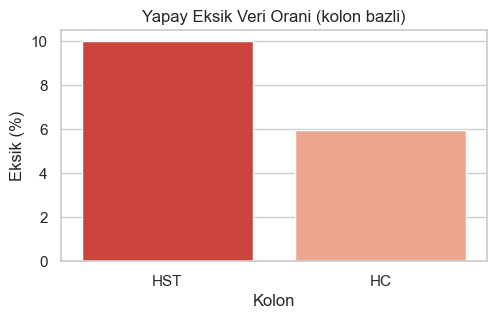

In [6]:
# Gercek veriyi bozmamak icin KOPYA uzerinde calisiyoruz
df_demo = df.copy()
np.random.seed(RANDOM_STATE)

# Iki kolona farkli oranlarda yapay eksik deger yerlestir
eksik_plani = {"HST": 0.10, "HC": 0.06}                        # kolon -> eksik oran
gercek_degerler = {c: df_demo[c].copy() for c in eksik_plani}  # dogrulama icin sakla
for kolon, oran in eksik_plani.items():
    idx = np.random.choice(df_demo.index, size=int(len(df_demo)*oran), replace=False)
    df_demo.loc[idx, kolon] = np.nan

# TESPIT: kolon bazli eksik yuzdesi
eksik_yuzde = df_demo[["HST","HC"]].isna().mean().mul(100)
print("Yapay olusturulan eksik veri oranlari (%):")
print(eksik_yuzde.round(1).to_string())

plt.figure(figsize=(5.5, 3))
sns.barplot(x=eksik_yuzde.index, y=eksik_yuzde.values,
            hue=eksik_yuzde.index, palette="Reds_r", legend=False)
plt.title("Yapay Eksik Veri Orani (kolon bazli)")
plt.ylabel("Eksik (%)"); plt.xlabel("Kolon")
plt.show()

In [7]:
# DOLDURMA: 3 yontemi karsilastir ve RMSE ile dogrula (ornek kolon: HST)
kolon = "HST"
maske  = df_demo[kolon].isna().values               # yapay eksik konumlar
gercek = gercek_degerler[kolon].values[maske]       # bu konumlardaki GERCEK degerler

# 1) Ortalama, 2) Medyan, 3) KNN (diger sayisal kolonlarin komsulugundan)
ort = SimpleImputer(strategy="mean").fit_transform(df_demo[[kolon]]).ravel()
med = SimpleImputer(strategy="median").fit_transform(df_demo[[kolon]]).ravel()
knn = KNNImputer(n_neighbors=5).fit_transform(df_demo[["HST","HS","HC","AST","AS"]])[:, 0]

print("Doldurma yontemi karsilastirmasi (dusuk RMSE = daha iyi):")
for ad, dolu in [("Ortalama", ort), ("Medyan", med), ("KNN (k=5)", knn)]:
    rmse = np.sqrt(np.mean((gercek - dolu[maske])**2))
    print(f"  {ad:12s} RMSE = {rmse:.3f}")

print("\nYORUM: KNN en dusuk RMSE'yi verdi, cunku iliskili kolonlardan (sut/korner) "
      "yararlanip her maca ozgu tahmin yapiyor; ortalama ve medyan ise tek kolona dayandigi "
      "icin benzer ve daha yuksek hata uretti. Bu bir GOSTERIMDIR; asil veri seti tam oldugu "
      "icin ana analize TAM (df) veriyle devam ediyoruz. Gercek bir eksiklik olsaydi en "
      "dusuk RMSE'li yontem (burada KNN) tercih edilirdi.")

Doldurma yontemi karsilastirmasi (dusuk RMSE = daha iyi):
  Ortalama     RMSE = 2.574
  Medyan       RMSE = 2.575
  KNN (k=5)    RMSE = 2.092

YORUM: KNN en dusuk RMSE'yi verdi, cunku iliskili kolonlardan (sut/korner) yararlanip her maca ozgu tahmin yapiyor; ortalama ve medyan ise tek kolona dayandigi icin benzer ve daha yuksek hata uretti. Bu bir GOSTERIMDIR; asil veri seti tam oldugu icin ana analize TAM (df) veriyle devam ediyoruz. Gercek bir eksiklik olsaydi en dusuk RMSE'li yontem (burada KNN) tercih edilirdi.


### 3.6 Aykırı Değer İncelemesi (IQR ve Z-score)
Aykırı değerleri, referans dersteki gibi iki yaygın yöntemle inceliyoruz: **IQR** (çeyrekler
açıklığı) ve **Z-score** (standart skor).

In [8]:
# 3.6 Aykiri deger: IQR ve Z-score (ornek: ev sahibi toplam sut HS)
q1, q3 = df["HS"].quantile([0.25, 0.75])
iqr = q3 - q1
alt, ust = q1 - 1.5*iqr, q3 + 1.5*iqr
iqr_aykiri = ((df["HS"] < alt) | (df["HS"] > ust)).sum()

z = np.abs(stats.zscore(df["HS"]))                  # her gozlemin standart skoru
z_aykiri = (z > 3).sum()                            # |z| > 3 esigi

print(f"IQR normal aralik: [{alt:.1f}, {ust:.1f}] -> aykiri: {iqr_aykiri} mac")
print(f"Z-score (|z|>3) -> aykiri: {z_aykiri} mac  (en yuksek HS = {df['HS'].max()})")
# Not: Bu degerler gercek maclara ait (cok sut atilan maclar). Hatali olmadiklari icin
# veriden CIKARMIYORUZ; sadece dagilimin uzun kuyruklu oldugunu not ediyoruz.

IQR normal aralik: [-0.9, 28.1] -> aykiri: 24 mac
Z-score (|z|>3) -> aykiri: 7 mac  (en yuksek HS = 36)


In [9]:
# 3.6 Turetilmis sutunlar (analiz ve modelleme icin)
df["TotalGoals"]  = df["FTHG"] + df["FTAG"]        # mactaki toplam gol
df["GoalDiff"]    = df["FTHG"] - df["FTAG"]        # gol farki (ev sahibi bakisi)
df["HomeWin"]     = (df["FTR"] == "H").astype(int) # ev kazandi mi (1/0)
df["SoTDiff"]     = df["HST"] - df["AST"]          # isabetli sut farki
df["ShotsDiff"]   = df["HS"]  - df["AS"]           # toplam sut farki
df["CornersDiff"] = df["HC"]  - df["AC"]           # korner farki
df["FoulsDiff"]   = df["HF"]  - df["AF"]           # faul farki
df["YellowDiff"]  = df["HY"]  - df["AY"]           # sari kart farki
df["RedDiff"]     = df["HR"]  - df["AR"]           # kirmizi kart farki
df["HTGoalDiff"]  = df["HTHG"] - df["HTAG"]        # ilk yari gol farki
print("Temizlenmis veri boyutu:", df.shape)
df[["Season","HomeTeam","AwayTeam","FTHG","FTAG","FTR","SoTDiff","HTGoalDiff"]].head()

Temizlenmis veri boyutu: (1520, 33)


,Season,HomeTeam,AwayTeam,FTHG,FTAG,FTR,SoTDiff,HTGoalDiff
0,2020-2021,Fulham,Arsenal,0,3,A,-4,-1
1,2020-2021,Crystal Palace,Southampton,1,0,H,-2,1
2,2020-2021,Liverpool,Leeds,4,3,H,3,1
3,2020-2021,West Ham,Newcastle,0,2,A,1,0
4,2020-2021,West Brom,Leicester,0,3,A,-6,0


## 4. Keşifsel Veri Analizi (EDA)
Önce temel istatistikleri çıkarıyor, ardından farklı türde **görselleştirmelerle**
(histogram, çubuk grafik, kutu grafik, saçılım grafiği, ısı haritası) verinin yapısını
inceliyoruz.

In [10]:
# Temel ozet istatistikler (ortalama, std, ceyrekler) + carpiklik (skewness)
ozet = df[["FTHG","FTAG","TotalGoals","HS","HST","HC","HY"]].describe().round(2)
print("Carpiklik (skewness) - TotalGoals:", round(df["TotalGoals"].skew(), 2),
      "  (>0 ise saga carpik: cogu macta az gol, az macta cok gol)")
ozet

Carpiklik (skewness) - TotalGoals: 0.53   (>0 ise saga carpik: cogu macta az gol, az macta cok gol)


,FTHG,FTAG,TotalGoals,HS,HST,HC,HY
count,1520.00,1520.00,1520.00,1520.00,1520.00,1520.00,1520.00
mean,1.58,1.34,2.91,14.00,4.89,5.73,1.66
std,1.37,1.25,1.72,5.83,2.67,3.10,1.27
min,0.00,0.00,0.00,1.00,0.00,0.00,0.00
25%,1.00,0.00,2.00,10.00,3.00,3.00,1.00
50%,1.00,1.00,3.00,14.00,5.00,5.00,2.00
75%,2.00,2.00,4.00,17.25,6.00,8.00,2.00
max,9.00,8.00,9.00,36.00,15.00,17.00,6.00


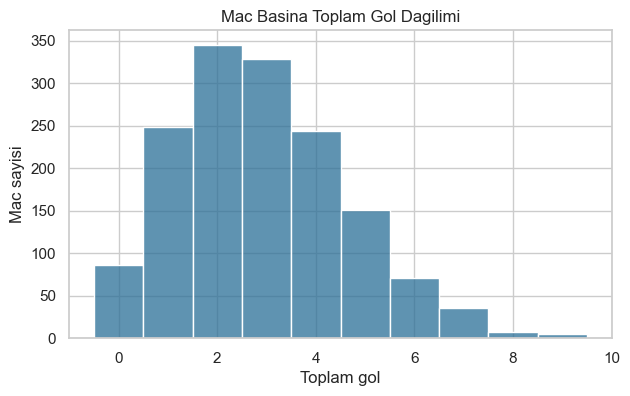

Ortalama gol/mac: 2.91


In [11]:
# GORSEL 1 (Histogram): Mac basina toplam gol dagilimi
plt.figure()
sns.histplot(df["TotalGoals"], bins=range(0, 10), discrete=True, color="#2a6f97")
plt.title("Mac Basina Toplam Gol Dagilimi")
plt.xlabel("Toplam gol"); plt.ylabel("Mac sayisi")
plt.show()
print("Ortalama gol/mac:", round(df["TotalGoals"].mean(), 2))

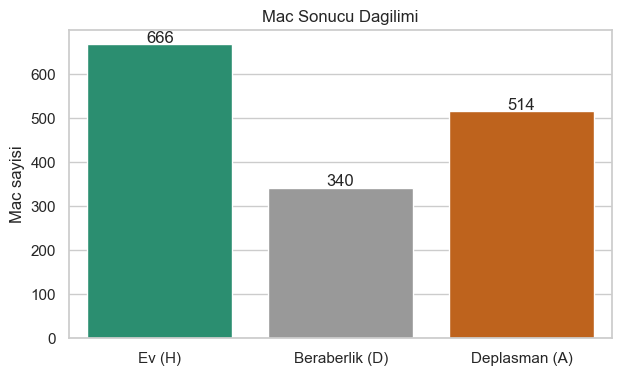

In [12]:
# GORSEL 2 (Cubuk grafik): Mac sonuclarinin dagilimi -> ev sahibi avantajinin ilk isareti
sira = ["H", "D", "A"]
etiket = {"H": "Ev (H)", "D": "Beraberlik (D)", "A": "Deplasman (A)"}
sayim = df["FTR"].value_counts().reindex(sira)
plt.figure()
sns.barplot(x=[etiket[s] for s in sira], y=sayim.values,
            hue=[etiket[s] for s in sira],
            palette=["#1b9e77","#999999","#d95f02"], legend=False)
for i, v in enumerate(sayim.values):
    plt.text(i, v + 5, str(v), ha="center")
plt.title("Mac Sonucu Dagilimi"); plt.ylabel("Mac sayisi")
plt.show()

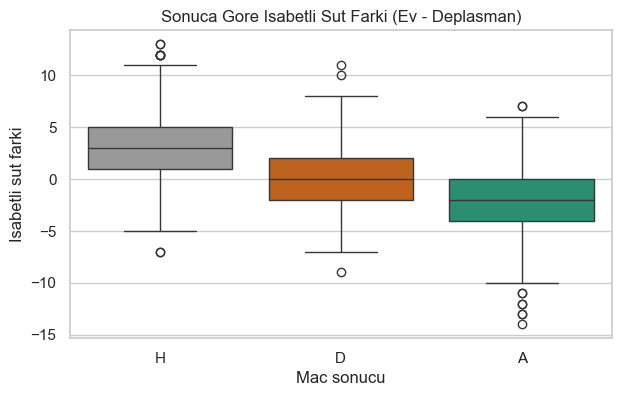

In [13]:
# GORSEL 3 (Kutu grafik): Sonuca gore isabetli sut farki
# Ev kazanan maclarda isabetli sut farkinin pozitif olmasini bekleriz.
plt.figure()
sns.boxplot(data=df, x="FTR", y="SoTDiff", order=sira, hue="FTR",
            palette=["#1b9e77","#999999","#d95f02"], legend=False)
plt.title("Sonuca Gore Isabetli Sut Farki (Ev - Deplasman)")
plt.xlabel("Mac sonucu"); plt.ylabel("Isabetli sut farki")
plt.show()

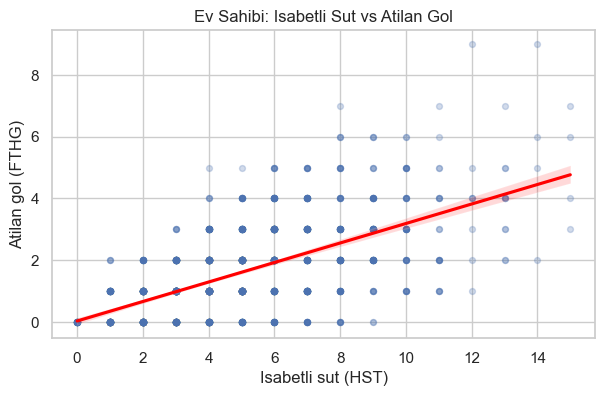

In [14]:
# GORSEL 4 (Sacilim grafigi): Ev sahibi isabetli sut sayisi vs attigi gol
plt.figure()
sns.regplot(data=df, x="HST", y="FTHG", scatter_kws={"alpha":0.25, "s":18},
            line_kws={"color":"red"})
plt.title("Ev Sahibi: Isabetli Sut vs Atilan Gol")
plt.xlabel("Isabetli sut (HST)"); plt.ylabel("Atilan gol (FTHG)")
plt.show()

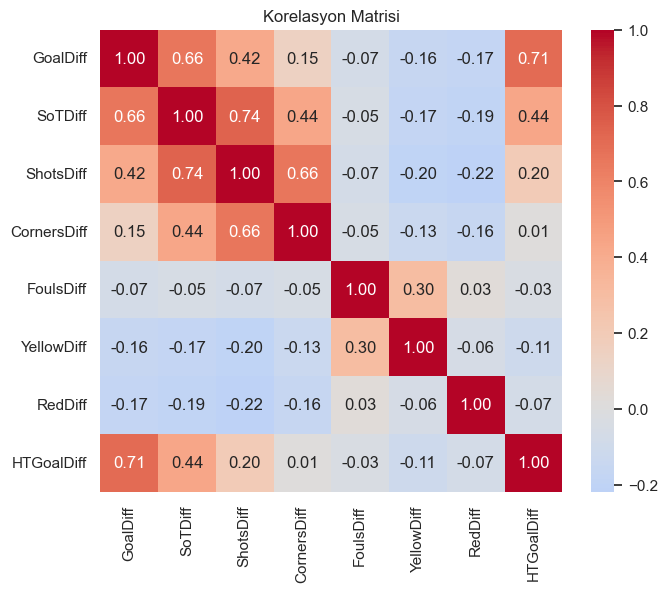

In [15]:
# GORSEL 5 (Isi haritasi): Sayisal degiskenler arasi korelasyon
korelasyon_sutunlari = ["GoalDiff","SoTDiff","ShotsDiff","CornersDiff",
                        "FoulsDiff","YellowDiff","RedDiff","HTGoalDiff"]
corr = df[korelasyon_sutunlari].corr()
plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Korelasyon Matrisi")
plt.show()

## 5. Araştırma Soruları

### Soru 1 — Ev sahibi avantajı gerçekten var mı?
Ev ve deplasman takımlarının galibiyet oranlarını ve ortalama gol sayılarını
karşılaştırıyoruz.

In [16]:
oran = df["FTR"].value_counts(normalize=True).mul(100).round(1)
print("Mac sonucu dagilimi (%):")
print(f"  Ev galibiyeti (H)      : %{oran['H']}")
print(f"  Beraberlik   (D)       : %{oran['D']}")
print(f"  Deplasman galibiyeti(A): %{oran['A']}")
print(f"\nOrtalama ev golu      : {df['FTHG'].mean():.2f}")
print(f"Ortalama deplasman golu: {df['FTAG'].mean():.2f}")
print(f"\nYORUM: Ev sahipleri maclarin ~%{oran['H']:.0f}'ini kazaniyor ve mac basina "
      f"ortalama {df['FTHG'].mean()-df['FTAG'].mean():.2f} gol daha fazla atiyor "
      "-> ev sahibi avantaji acikca gozlemleniyor.")

Mac sonucu dagilimi (%):
  Ev galibiyeti (H)      : %43.8
  Beraberlik   (D)       : %22.4
  Deplasman galibiyeti(A): %33.8

Ortalama ev golu      : 1.57
Ortalama deplasman golu: 1.34

YORUM: Ev sahipleri maclarin ~%44'ini kazaniyor ve mac basina ortalama 0.24 gol daha fazla atiyor -> ev sahibi avantaji acikca gozlemleniyor.


**Bu fark istatistiksel olarak anlamlı mı? (Hipotez testi)**
Gözlenen ev sahibi üstünlüğünün rastlantı olup olmadığını bir **binom testiyle** sınıyoruz.
Beraberlik olmayan (kesin sonuçlu) maçlara bakıyoruz:
- **H₀ (sıfır hipotezi):** Ev sahibinin kazanma olasılığı = 0.5 (avantaj yok)
- **H₁ (alternatif):** Olasılık ≠ 0.5

In [17]:
# S1 - Cikarimsal istatistik: ev sahibi avantaji ISTATISTIKSEL olarak anlamli mi?
ev_galip  = (df["FTR"] == "H").sum()
dep_galip = (df["FTR"] == "A").sum()
kesin = ev_galip + dep_galip                          # beraberlik olmayan maclar

test = binomtest(ev_galip, kesin, p=0.5, alternative="two-sided")
print(f"Kesin sonuclu mac : {kesin}")
print(f"Ev galibiyeti     : {ev_galip}  (kesin maclarin %{ev_galip/kesin*100:.1f}'i)")
print(f"Binom testi p-degeri: {test.pvalue:.3e}")
print("\nSONUC: p < 0.05 -> H0 reddedilir; ev sahibi avantaji ISTATISTIKSEL OLARAK ANLAMLI."
      if test.pvalue < 0.05 else "p >= 0.05 -> fark anlamli degil.")

Kesin sonuclu mac : 1180
Ev galibiyeti     : 666  (kesin maclarin %56.4'i)
Binom testi p-degeri: 1.075e-05

SONUC: p < 0.05 -> H0 reddedilir; ev sahibi avantaji ISTATISTIKSEL OLARAK ANLAMLI.


### Soru 2 — Hangi maç içi istatistik, gol farkıyla en güçlü ilişkilidir?
Türetilmiş fark değişkenlerinin gol farkıyla (maç üstünlüğü) korelasyonuna bakıyoruz.

In [18]:
gd_corr = corr["GoalDiff"].drop("GoalDiff").sort_values(ascending=False)
print("GoalDiff ile korelasyon (buyukten kucuge):")
print(gd_corr.round(3).to_string())
print(f"\nYORUM: Ilk yari gol farki disinda, oyun icindeki en guclu belirleyici "
      f"ISABETLI SUT farki (r={gd_corr['SoTDiff']:.2f}). Kartlar (sari/kirmizi) ile "
      "iliski NEGATIF: cok kart goren takim genelde geride olan/baskilanan taraftir.")

GoalDiff ile korelasyon (buyukten kucuge):
HTGoalDiff     0.706
SoTDiff        0.659
ShotsDiff      0.422
CornersDiff    0.148
FoulsDiff     -0.073
YellowDiff    -0.156
RedDiff       -0.174

YORUM: Ilk yari gol farki disinda, oyun icindeki en guclu belirleyici ISABETLI SUT farki (r=0.66). Kartlar (sari/kirmizi) ile iliski NEGATIF: cok kart goren takim genelde geride olan/baskilanan taraftir.


### Soru 3 — İlk yarıyı önde kapatmak maç sonucunu ne kadar belirler?
İlk yarı sonucu (HTR) ile maç sonu sonucu (FTR) arasındaki koşullu olasılıkları
çapraz tablo ile inceliyoruz.

Satir yuzdesi: ilk yari sonucu (HTR) -> mac sonu (FTR)
FTR     H     D     A
HTR                  
A    10.9  16.4  72.7
D    36.5  32.8  30.7
H    78.2  14.8   7.0


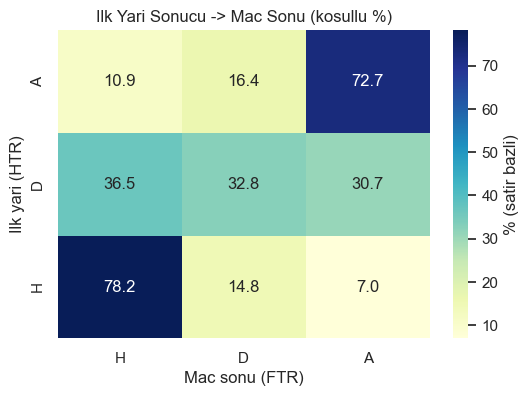


YORUM: Devreyi onde kapatan ev sahibi maclarin %78'ini kazaniyor; devreyi onde kapatan deplasman ise %73 oraninda kazaniyor. Ilk yari ustunlugu sonucun guclu bir habercisi.


In [19]:
capraz = pd.crosstab(df["HTR"], df["FTR"], normalize="index").mul(100).round(1)
capraz = capraz[["H","D","A"]]
print("Satir yuzdesi: ilk yari sonucu (HTR) -> mac sonu (FTR)")
print(capraz)

plt.figure(figsize=(6, 4))
sns.heatmap(capraz, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={"label": "% (satir bazli)"})
plt.title("Ilk Yari Sonucu -> Mac Sonu (kosullu %)")
plt.xlabel("Mac sonu (FTR)"); plt.ylabel("Ilk yari (HTR)")
plt.show()

print(f"\nYORUM: Devreyi onde kapatan ev sahibi maclarin %{capraz.loc['H','H']:.0f}'ini "
      f"kazaniyor; devreyi onde kapatan deplasman ise %{capraz.loc['A','A']:.0f} "
      "oraninda kazaniyor. Ilk yari ustunlugu sonucun guclu bir habercisi.")

## 6. Modelleme — Maç Sonucu Sınıflandırması
Maç içi istatistik **farklarını** kullanarak maç sonucunu (H / D / A) tahmin eden bir
**Lojistik Regresyon** modeli kuruyoruz. Model yorumlanabilir olduğu için tercih edildi.

> **Önemli not:** Özellikler maç içi istatistiklerdir (maç oynanırken oluşur). Bu nedenle
> model, maç öncesi bir *tahmin* aracı değil; *hangi oyun dinamiklerinin sonuçla ilişkili
> olduğunu* açıklayan bir modeldir. Maç sonu gol sayıları (FTHG/FTAG) özellik olarak
> **kullanılmaz**, çünkü sonucu doğrudan tanımlarlar.

### Kullanılan `scikit-learn` (sklearn) bileşenleri
Modelleme ve veri hazırlığı adımlarını sıfırdan kodlamak yerine scikit-learn'in hazır
bileşenlerini kullanıyoruz. Bu projede kullandığımız sklearn parçaları ve görevleri:

| sklearn parçası | Görevi |
| --- | --- |
| `train_test_split` | Veriyi eğitim/test olarak böler (görülmeyen veride sınamak için) |
| `StandardScaler` | Değişkenleri aynı ölçeğe getirir (lojistik regresyon için önemli) |
| `LogisticRegression` | Modelin kendisi — matematiği bizim yerimize uygular |
| `accuracy_score`, `classification_report`, `confusion_matrix` | Modeli değerlendirir |
| `DummyClassifier` | Karşılaştırma için naif taban çizgisi üretir |
| `SimpleImputer`, `KNNImputer` | Eksik veri doldurma (temizleme bölümündeki gösterim) |

In [20]:
# Ozellikler (mac ici istatistik farklari) ve hedef (mac sonucu)
ozellikler = ["SoTDiff","ShotsDiff","CornersDiff","FoulsDiff",
              "YellowDiff","RedDiff","HTGoalDiff"]
X = df[ozellikler]
y = df["FTR"]

# Egitim/test ayrimi (sinif oranlarini koruyarak)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Egitim seti:", X_tr.shape, "| Test seti:", X_te.shape)

# Olceklendirme (lojistik regresyon icin onemli)
olcek = StandardScaler().fit(X_tr)
X_tr_s = olcek.transform(X_tr)
X_te_s = olcek.transform(X_te)

Egitim seti: (1216, 7) | Test seti: (304, 7)


In [21]:
# Modeli egit
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_tr_s, y_tr)
tahmin = model.predict(X_te_s)

# Taban cizgisi: her zaman en sik sinifi ('H') tahmin eden naif model
taban = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
taban_dogruluk = accuracy_score(y_te, taban.predict(X_te))

print(f"Taban cizgisi dogrulugu : {taban_dogruluk:.3f}")
print(f"Lojistik regresyon       : {accuracy_score(y_te, tahmin):.3f}")
print("\nSiniflandirma raporu:")
print(classification_report(y_te, tahmin))

Taban cizgisi dogrulugu : 0.438
Lojistik regresyon       : 0.641

Siniflandirma raporu:
              precision    recall  f1-score   support

           A       0.66      0.71      0.68       103
           D       0.28      0.07      0.12        68
           H       0.67      0.88      0.76       133

    accuracy                           0.64       304
   macro avg       0.53      0.55      0.52       304
weighted avg       0.58      0.64      0.59       304



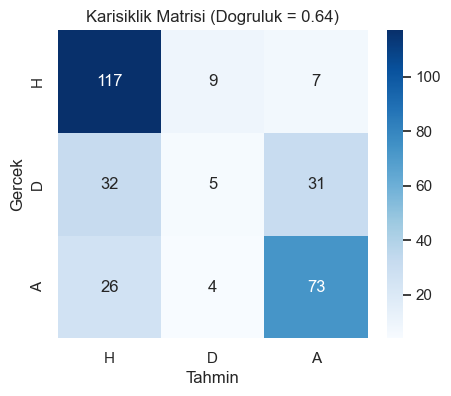

In [22]:
# Karisiklik matrisi (gercek vs tahmin)
cm = confusion_matrix(y_te, tahmin, labels=["H","D","A"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["H","D","A"], yticklabels=["H","D","A"])
plt.title(f"Karisiklik Matrisi (Dogruluk = {accuracy_score(y_te, tahmin):.2f})")
plt.xlabel("Tahmin"); plt.ylabel("Gercek")
plt.show()

In [23]:
# Katsayi yorumu: 'H' (ev galibiyeti) sinifini artiran/azaltan ozellikler
katsayi = pd.DataFrame(model.coef_, columns=ozellikler, index=model.classes_).T
print("Olceklenmis katsayilar (sinif bazli):")
print(katsayi.round(2))
print("\nYORUM: 'H' sutununda pozitif ve buyuk katsayilar (ozellikle HTGoalDiff ve "
      "SoTDiff) ev galibiyeti olasiligini artirir; kirmizi/sari kart farki ev sahibi "
      "lehine arttikca (ev sahibi daha cok kart gordukce) ev galibiyeti olasiligi duser.")

Olceklenmis katsayilar (sinif bazli):
                A     D     H
SoTDiff     -0.98  0.06  0.92
ShotsDiff   -0.04 -0.12  0.16
CornersDiff  0.21  0.05 -0.26
FoulsDiff    0.10 -0.04 -0.06
YellowDiff   0.01 -0.02  0.00
RedDiff      0.19 -0.05 -0.13
HTGoalDiff  -1.16  0.03  1.13

YORUM: 'H' sutununda pozitif ve buyuk katsayilar (ozellikle HTGoalDiff ve SoTDiff) ev galibiyeti olasiligini artirir; kirmizi/sari kart farki ev sahibi lehine arttikca (ev sahibi daha cok kart gordukce) ev galibiyeti olasiligi duser.


## 7. Sonuçların Tema Bağlamında Yorumlanması

- **Ev sahibi avantajı (S1):** 1520 maçlık örneklemde ev sahipleri maçların ~%44'ünü
  kazanıyor (deplasman ~%34), maç başına ortalama ~0.24 gol fazla atıyor. Binom testi bu
  farkın **istatistiksel olarak anlamlı** olduğunu (p≪0.05) gösteriyor; yani gözlenen ev
  sahibi avantajı rastlantı değil. Bu, futbolda iyi bilinen olguyu veriyle doğruluyor.
- **Belirleyici istatistik (S2):** İlk yarı gol farkı dışında, sonucu en güçlü
  haber veren oyun istatistiği **isabetli şut farkıdır** (r≈0.66). Toplam şut (miktar)
  isabetli şut (kalite) kadar belirleyici değildir. Kartların negatif ilişkisi, kartın
  bir "neden" değil çoğunlukla geride/baskı altında olmanın bir "sonucu" olduğunu gösterir.
- **İlk yarı üstünlüğü (S3):** Devreyi önde kapatan ev sahibi maçların ~%78'ini
  kazanıyor — ilk yarı sonucu güçlü bir öngörücü.
- **Model:** Lojistik regresyon test doğruluğu ~%64 ile taban çizgisinin (~%44) belirgin
  üzerinde. Model **ev** ve **deplasman** galibiyetlerini iyi ayırırken **beraberlikleri**
  neredeyse hiç yakalayamıyor (beraberlik için recall çok düşük). Bu, futbolda
  beraberliklerin istatistiksel olarak "ayırt edici imzası" zayıf, dengeli maçlar olmasıyla
  tutarlıdır.

## 8. Sınırlamalar ve Öğrenilenler

**Sınırlamalar**
- Özellikler maç içi istatistiklerdir; model maç **öncesi** tahmin yapmaz, sonucu
  *açıklar*. Gerçek bir tahmin sistemi için maç öncesi değişkenler (form, kadro, oran)
  gerekir.
- Yalnızca tek lig (Premier Lig) ve 4 sezon kullanıldı; başka liglere genellenemeyebilir.
- Beraberlik sınıfı modellenmesi zor; sınıf dengesizliği ve beraberliklerin doğası
  performansı sınırlıyor.
- Hiperparametre optimizasyonu yapılmadı (proje kapsamı gereği tek savunulabilir model).

**Öğrenilenler**
- Veri temizleme (tip dönüşümü, eksik/aykırı değer) analizden önce gelen kritik adımdır;
  eksik veriyi doldururken (imputation) yöntem seçimi RMSE gibi bir ölçütle doğrulanmalıdır.
- Bir farkı gözlemlemek ile onun **istatistiksel olarak anlamlı** olduğunu göstermek
  ayrı şeylerdir; hipotez testi (binom testi) bu boşluğu doldurur.
- Korelasyon nedensellik değildir (kart örneği bunu net gösteriyor).
- Basit, yorumlanabilir bir model (lojistik regresyon) bile temayla ilgili anlamlı,
  savunulabilir içgörüler üretebilir.